## Setup

Loading the cleaned, feature-engineered AirPassengers dataset (prepared in the earlier EDA/feature-engineering notebook) along with the exponential smoothing models from `statsmodels` and the evaluation metrics we'll use throughout.

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,mean_absolute_percentage_error, r2_score

## Load the prepared dataset

The dataframe was serialized with `joblib` after feature engineering (lags, rolling means/stds, calendar features). Exponential smoothing models only need the target column (`#Passengers`), but keeping the extra columns around lets us inspect the series alongside its engineered features.

In [2]:
df= joblib.load(r"C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl")

In [3]:
df.head()

,#Passengers,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [4]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   #Passengers    144 non-null    int64  
 1   month          144 non-null    int32  
 2   quarter        144 non-null    int32  
 3   lag1           143 non-null    float64
 4   lag2           142 non-null    float64
 5   lag3           141 non-null    float64
 6   rolling_mean3  142 non-null    float64
 7   rolling_std3   142 non-null    float64
 8   rolling_mean6  139 non-null    float64
 9   rolling_std6   139 non-null    float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 11.2 KB
None


,#Passengers,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
count,144.000000,144.000000,144.000000,143.000000,142.000000,141.000000,142.000000,142.000000,139.000000,139.000000
mean,280.298611,6.500000,2.500000,279.237762,278.457746,277.163121,280.500000,24.125941,280.151079,34.415635
std,119.966317,3.464102,1.121936,119.708270,119.766772,119.192439,116.940083,17.180862,111.943814,20.641465
min,104.000000,1.000000,1.000000,104.000000,104.000000,104.000000,112.333333,1.154701,119.666667,8.916277
25%,180.000000,3.750000,1.750000,180.000000,180.000000,180.000000,184.916667,12.013857,182.416667,18.978871
50%,265.500000,6.500000,2.500000,264.000000,264.000000,264.000000,261.666667,20.219624,259.166667,26.515404
75%,360.500000,9.250000,3.250000,359.500000,358.250000,356.000000,357.666667,31.873737,362.416667,46.286518
max,622.000000,12.000000,4.000000,622.000000,622.000000,622.000000,587.666667,76.872188,534.000000,94.200672


## Index integrity and missing values

Exponential smoothing in `statsmodels` needs a well-formed, gap-free `DatetimeIndex` with an explicit frequency — otherwise `.forecast()` can't infer the correct step size. We check:
- `index.freq` is set (should be `MS`, month-start)
- no duplicate index entries
- how many NaNs exist (expected: a handful at the start of the lag/rolling-window columns, since there's no prior data to compute them from)

Missing lag/rolling values are backfilled — reasonable here since it only affects the first few rows of engineered features, not the target itself.

In [5]:
print(df.index.freq)
print(df.index.dtype)
print(df.shape)
print(df.isnull().sum())
print(df.index.duplicated().sum())
df.bfill(inplace=True)
print(df.isnull().sum())

<MonthBegin>
datetime64[ns]
(144, 10)
#Passengers      0
month            0
quarter          0
lag1             1
lag2             2
lag3             3
rolling_mean3    2
rolling_std3     2
rolling_mean6    5
rolling_std6     5
dtype: int64
0
#Passengers      0
month            0
quarter          0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64


In [6]:
train= df.iloc[:-12,:]
test= df.iloc[-12:,:]

In [7]:
print(train.index.freq)
print(train.index.dtype)
print(train.shape)
print(train.isnull().sum())
print(train.index.duplicated().sum())

<MonthBegin>
datetime64[ns]
(132, 10)
#Passengers      0
month            0
quarter          0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64
0


# Simple Exponential Smoothing (SES)

SES weights recent observations more heavily via a single smoothing parameter `alpha`, with no explicit trend or seasonal component. It's the baseline here — useful mainly to quantify how much trend/seasonal modeling actually buys us.

In [8]:
simple_model= SimpleExpSmoothing(train['#Passengers']).fit()

In [9]:
simple_model.summary()

Dep. Variable:,#Passengers,No. Observations:,132
Model:,SimpleExpSmoothing,SSE,128603.001
Optimized:,True,AIC,912.382
Trend:,None,BIC,918.148
Seasonal:,None,AICC,912.697
Seasonal Periods:,None,Date:,"Sat, 22 Aug 2026"
Box-Cox:,False,Time:,14:08:20
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
initial_level,112.00000,l.0,False


In [10]:
simple_pred= simple_model.forecast(len(test))

In [11]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= mean_absolute_percentage_error(test, predictions)
  mape= round(mape * 100, 2)
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')

  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value
  

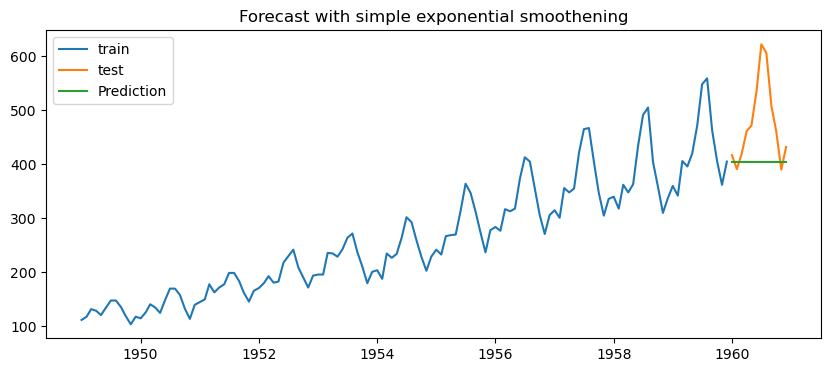

mean absolute error: 76.0
mean absolute percentage error: 14.25%
r2 score: -0.91
root mean squared error: 102.98


,mae,mape,r2,rmse
0,76.0,14.25,-0.91,102.98


In [12]:
model_evaluator(train['#Passengers'],test['#Passengers'],simple_pred, 'simple exponential smoothening')

# Double Exponential Smoothing (Holt's Linear Trend)

Adds an additive trend component (`trend='mul'`) on top of SES. Still no seasonality, so we'd expect this to underperform on a series with the strong yearly cycle we saw in the decomposition — worth confirming against the metrics below rather than assuming.

In [13]:


double_smoothening= ExponentialSmoothing(train['#Passengers'],
                                         seasonal=None,
                                         trend='mul',
                                         ).fit()

In [14]:
double_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,132
Model:,ExponentialSmoothing,SSE,128590.444
Optimized:,True,AIC,916.369
Trend:,Multiplicative,BIC,927.901
Seasonal:,None,AICC,917.041
Seasonal Periods:,None,Date:,"Sat, 22 Aug 2026"
Box-Cox:,False,Time:,14:08:26
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.000000,beta,True


In [15]:
double_pred= double_smoothening.forecast(len(test))

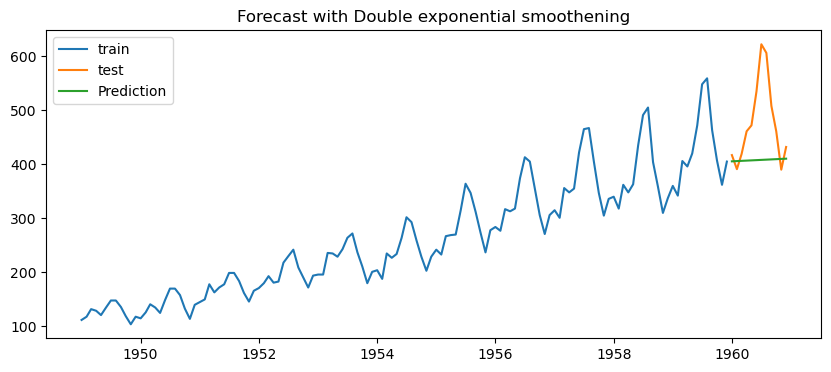

mean absolute error: 74.07
mean absolute percentage error: 13.89%
r2 score: -0.83
root mean squared error: 100.79


,mae,mape,r2,rmse
0,74.07,13.89,-0.83,100.79


In [16]:
model_evaluator(train['#Passengers'],test['#Passengers'],double_pred, 'Double exponential smoothening')

# Triple Exponential Smoothing (Holt-Winters)

Adds a seasonal component on top of trend. `trend='mul'` and `seasonal='mul'` are chosen (rather than `'add'`) because the seasonal decomposition earlier showed the amplitude of the seasonal swings **growing** as the passenger volume grows a multiplicative pattern. An additive model would assume a constant seasonal swing in absolute terms, which doesn't match what the data shows.

In [17]:
triple_smoothening= ExponentialSmoothing(train['#Passengers'],
                                         seasonal='mul',
                                         trend='mul',
                                         seasonal_periods=12).fit()

In [18]:
triple_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,132
Model:,ExponentialSmoothing,SSE,12210.593
Optimized:,True,AIC,629.598
Trend:,Multiplicative,BIC,675.723
Seasonal:,Multiplicative,AICC,635.651
Seasonal Periods:,12,Date:,"Sat, 22 Aug 2026"
Box-Cox:,False,Time:,14:08:28
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3672281,alpha,True
smoothing_trend,0.000000,beta,True


In [19]:
triple_pred= triple_smoothening.forecast(len(test))

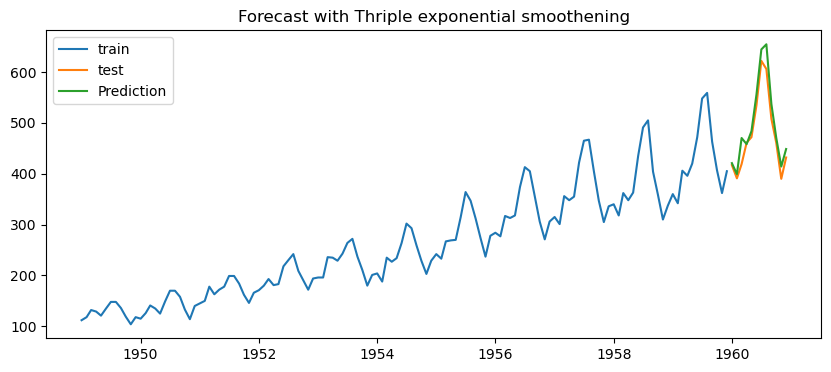

mean absolute error: 20.86
mean absolute percentage error: 4.33%
r2 score: 0.88
root mean squared error: 25.82


In [20]:
triple_metrics=model_evaluator(train['#Passengers'],test['#Passengers'],triple_pred, 'Thriple exponential smoothening')

In [21]:
triple_metrics.to_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\triple_metric.csv')

In [22]:
# Predicting the future

final_exponential_smoothening= ExponentialSmoothing(df['#Passengers'],
                                                   seasonal='mul',
                                                  trend='mul',
                                                  seasonal_periods=12 ).fit()

In [23]:
final_exponential_smoothening.summary()

Dep. Variable:,#Passengers,No. Observations:,144
Model:,ExponentialSmoothing,SSE,15805.297
Optimized:,True,AIC,708.553
Trend:,Multiplicative,BIC,756.070
Seasonal:,Multiplicative,AICC,714.025
Seasonal Periods:,12,Date:,"Sat, 22 Aug 2026"
Box-Cox:,False,Time:,14:08:30
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2919014,alpha,True
smoothing_trend,0.000000,beta,True


In [24]:
next_12_months= final_exponential_smoothening.forecast(12)

In [25]:
next_12_months

1961-01-01    450.675656
1961-02-01    424.818973
1961-03-01    475.495692
1961-04-01    504.076613
1961-05-01    517.872530
1961-06-01    590.146406
1961-07-01    684.227918
1961-08-01    678.031811
1961-09-01    567.112436
1961-10-01    507.824237
1961-11-01    434.719191
1961-12-01    485.980823
Freq: MS, dtype: float64

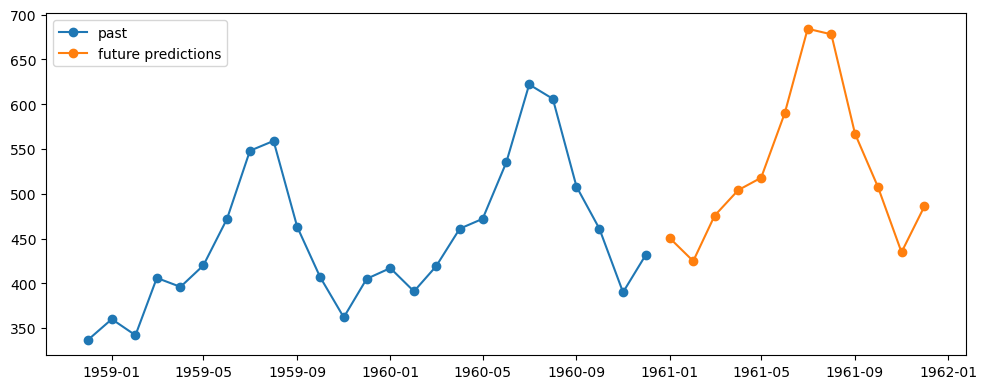

In [26]:
plt.figure(figsize=(10,4))

plt.plot(df['#Passengers'].iloc[-25:], label= 'past', marker='o')
plt.plot(next_12_months, label='future predictions', marker='o')

plt.legend()
plt.tight_layout()
plt.show()

## Saving the model

Persisting the fitted model so it can be loaded directly for inference later without retraining, and so it's available for the cross-model comparison notebook.

In [27]:
joblib.dump(final_exponential_smoothening, r"C:\Users\MINE\Desktop\Air passenger prediction\models\expo_smoothening.pkl" )

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\expo_smoothening.pkl']